# 02B · Análisis exploratorio temporal, de actores y espacial
## Actividad 3.1 del cronograma · escenario con víctimas

Este notebook analiza siniestros **registrados**, no riesgo individual ni efectos causales. Usa 2018–2024 y el indicador tradicional, igual que el modelo principal. Incluye calendario completo, promedios por día, festivos, pandemia, actores y controles con polígonos oficiales. No modifica el dataset del modelo. La cartografía descargada es una referencia actual: no acredita límites históricos ni corrige automáticamente localidades de los registros.

## 1. Fuente, alcance y controles básicos

In [1]:
from pathlib import Path
from hashlib import sha256
import json, urllib.request, urllib.parse, unicodedata
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import shapely
from shapely.geometry import shape
from shapely.ops import transform
from pyproj import Transformer
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/raw/base-anuario-de-siniestralidad-2024.xlsx').exists())
RAW_FILE = ROOT/'data/raw/base-anuario-de-siniestralidad-2024.xlsx'
REPORTS_PATH = ROOT/'reports/eda_victimas'
REPORTS_PATH.mkdir(parents=True,exist_ok=True)
protected_files = [p for folder in ['data/processed','models'] for p in (ROOT/folder).rglob('*') if p.is_file()]
protected_hashes = {p:sha256(p.read_bytes()).hexdigest() for p in [RAW_FILE,*protected_files]}
plt.style.use('seaborn-v0_8-whitegrid'); pd.set_option('display.max_columns',30)
SLOTS = ['Madrugada','Mañana','Tarde','Noche']
DAYS = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
FLAGS = {'Motocicleta':'Con_Moto','Peatón':'Con_Peaton','Bicicleta':'Con_Bicicleta'}
cols = ['Codigo_Accidente','Longitud','Latitud','Fecha_Acc','AA_Acc','Hora_Acc','Localidad',
        'Gravedad_Indicador_Tradicional','Gravedad_indicador_30d',*FLAGS.values()]
raw = pd.read_excel(RAW_FILE,sheet_name='Siniestros',usecols=cols)
raw['Fecha_Acc'] = pd.to_datetime(raw.Fecha_Acc).dt.normalize()
period_raw = raw[raw.Fecha_Acc.between('2018-01-01','2024-12-31')].copy()
victimas = period_raw[period_raw.Gravedad_Indicador_Tradicional.isin(['Con Heridos','Con Muertos'])].copy()
assert victimas.Codigo_Accidente.notna().all() and victimas.Codigo_Accidente.is_unique
assert victimas.Hora_Acc.between(0,23).all()
assert (victimas.AA_Acc == victimas.Fecha_Acc.dt.year).all()
assert len(victimas)==85199
victimas['Franja_Horaria'] = pd.cut(victimas.Hora_Acc,[-1,5,11,17,23],labels=SLOTS)
victimas['Dia_Num'] = victimas.Fecha_Acc.dt.dayofweek
victimas['Dia_Semana'] = victimas.Dia_Num.map(dict(enumerate(DAYS)))
victimas['Mes'] = victimas.Fecha_Acc.dt.month
def export(frame,name,index=False):
    frame.to_csv(REPORTS_PATH/name,index=index,encoding='utf-8-sig')
def savefig(name):
    plt.tight_layout(); plt.savefig(REPORTS_PATH/name,dpi=170,bbox_inches='tight'); plt.show(); plt.close()
print(f'{len(victimas):,} siniestros con víctimas; {victimas.Localidad.nunique()} localidades.')
display(victimas[['AA_Acc','Gravedad_Indicador_Tradicional']].value_counts().sort_index().rename('Siniestros').to_frame())

85,199 siniestros con víctimas; 20 localidades.


Siniestros
AA_Acc Gravedad_Indicador_Tradicional            
2018   Con Heridos                          12614
       Con Muertos                            501
2019   Con Heridos                          12376
       Con Muertos                            493
2020   Con Heridos                           8570
       Con Muertos                            370
2021   Con Heridos                          11006
       Con Muertos                            462
2022   Con Heridos                          12355
       Con Muertos                            541
2023   Con Heridos                          12454
       Con Muertos                            545
2024   Con Heridos                          12343
       Con Muertos                            569

## 2. Gravedad y unidades de análisis

Un siniestro con fallecidos no equivale a una persona fallecida. Se conserva la definición tradicional y se cuantifica, sin cambiar el modelo, su diferencia con el indicador a treinta días. Los faltantes del segundo indicador se muestran explícitamente.

In [2]:
cross_gravity = pd.crosstab(period_raw.Gravedad_Indicador_Tradicional,
                             period_raw.Gravedad_indicador_30d.fillna('Sin información'))
export(cross_gravity,'comparacion_indicadores_gravedad.csv',index=True)
a = period_raw.Gravedad_Indicador_Tradicional.isin(['Con Heridos','Con Muertos'])
b = period_raw.Gravedad_indicador_30d.isin(['Con Heridos','Con Muertos'])
gravity_membership = pd.DataFrame([{'Victimas_Tradicional':int(a.sum()),'Victimas_30d':int(b.sum()),
    'Salen_Al_Cambiar':int((a&~b).sum()),'Entran_Al_Cambiar':int((~a&b).sum()),
    'Indicador30d_Faltante_En_Tradicional':int((a & period_raw.Gravedad_indicador_30d.isna()).sum())}])
export(gravity_membership,'sensibilidad_universo_gravedad.csv')
display(cross_gravity); display(gravity_membership)

Gravedad_indicador_30d,Con Heridos,Con Muertos,Sin información,Solo Daños
Gravedad_Indicador_Tradicional,,,,
Con Heridos,81642,0,16,60
Con Muertos,125,3355,0,1
Solo Daños,21,0,79,91800


,Victimas_Tradicional,Victimas_30d,Salen_Al_Cambiar,Entran_Al_Cambiar,Indicador30d_Faltante_En_Tradicional
0,85199,85143,77,21,16


## 3. Calendario completo y serie mensual

El denominador es el número de días calendario, incluidos los días sin registros. Promedio por día no es una tasa por exposición al tránsito. La serie mensual evita comparar meses solo por totales de distinta duración. Se destaca 2020 descriptivamente; no se estima un efecto causal de la pandemia.

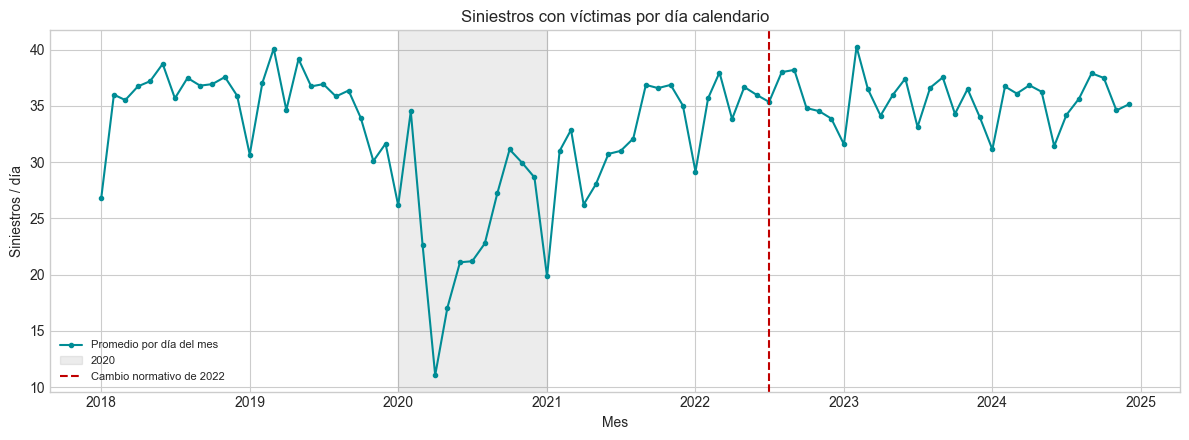

,Siniestros,Dias,Promedio_Diario,Ratio_vs_2018_2019
Anio,,,,
2018,13115,365,35.932,1.009
2019,12869,365,35.258,0.991
2020,8940,366,24.426,0.686
2021,11468,365,31.419,0.883
2022,12896,365,35.332,0.993
2023,12999,365,35.614,1.001
2024,12912,366,35.279,0.991


In [3]:
calendar = pd.DataFrame({'Fecha_Acc':pd.date_range('2018-01-01','2024-12-31',freq='D')})
calendar['Anio'] = calendar.Fecha_Acc.dt.year
calendar['Mes'] = calendar.Fecha_Acc.dt.month
calendar['Dia_Num'] = calendar.Fecha_Acc.dt.dayofweek
calendar['Dia_Semana'] = calendar.Dia_Num.map(dict(enumerate(DAYS)))
festivos = holidays.CO(years=range(2018,2025))
calendar['Es_Festivo'] = calendar.Fecha_Acc.dt.date.map(lambda d:d in festivos)
calendar['Nombre_Festivo'] = calendar.Fecha_Acc.dt.date.map(lambda d:festivos.get(d,''))
daily = calendar.merge(victimas.groupby('Fecha_Acc').size().rename('Siniestros'),on='Fecha_Acc',how='left')
daily['Siniestros'] = daily.Siniestros.fillna(0).astype(int)
assert len(daily)==2557 and daily.Siniestros.sum()==len(victimas)
victimas = victimas.merge(calendar[['Fecha_Acc','Es_Festivo']],on='Fecha_Acc',validate='many_to_one')
monthly = daily.groupby(['Anio','Mes']).agg(Siniestros=('Siniestros','sum'),Dias=('Fecha_Acc','size'),
                                          Promedio_Diario=('Siniestros','mean')).reset_index()
monthly['Inicio_Mes'] = pd.to_datetime(dict(year=monthly.Anio,month=monthly.Mes,day=1))
annual = daily.groupby('Anio').agg(Siniestros=('Siniestros','sum'),Dias=('Fecha_Acc','size'),Promedio_Diario=('Siniestros','mean'))
prepandemic = daily[daily.Anio.isin([2018,2019])].Siniestros.mean()
annual['Ratio_vs_2018_2019'] = annual.Promedio_Diario/prepandemic
export(daily,'serie_diaria_calendario.csv'); export(monthly,'serie_mensual.csv'); export(annual,'resumen_anual.csv',index=True)
fig,ax=plt.subplots(figsize=(12,4.5))
ax.plot(monthly.Inicio_Mes,monthly.Promedio_Diario,color='#008C95',marker='.',label='Promedio por día del mes')
ax.axvspan(pd.Timestamp('2020-01-01'),pd.Timestamp('2021-01-01'),color='gray',alpha=.15,label='2020')
ax.axvline(pd.Timestamp('2022-07-01'),ls='--',color='#C00000',label='Cambio normativo de 2022')
ax.set(title='Siniestros con víctimas por día calendario',ylabel='Siniestros / día',xlabel='Mes')
ax.legend(fontsize=8); savefig('05_serie_temporal_mensual.png')
display(annual.round(3))

## 4. Día de semana × franja y estacionalidad mensual

Se incluyen las 28 combinaciones de día de semana y franja, también las de conteo cero. Cada celda se divide entre la cantidad de días de ese tipo en 2018–2024. No se suman ni comparan estos promedios como si midieran riesgo individual.

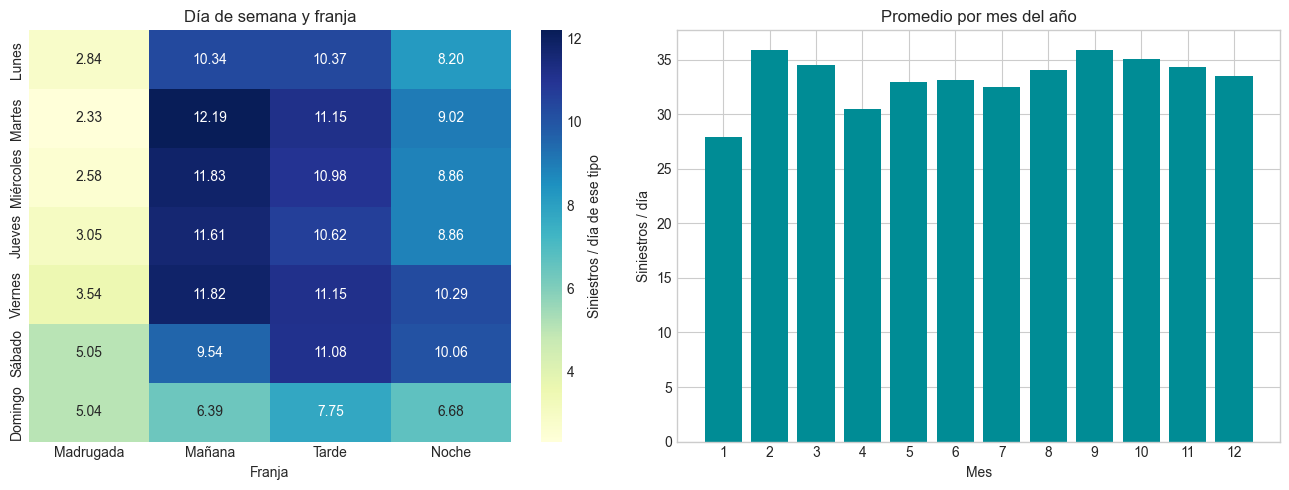

In [4]:
weekday_den = calendar.groupby('Dia_Num').size()
idx = pd.MultiIndex.from_product([range(7),SLOTS],names=['Dia_Num','Franja_Horaria'])
weekday_slot = victimas.groupby(['Dia_Num','Franja_Horaria'],observed=True).size().reindex(idx,fill_value=0).rename('Siniestros').reset_index()
weekday_slot['Dias_Calendario'] = weekday_slot.Dia_Num.map(weekday_den)
weekday_slot['Promedio_Diario'] = weekday_slot.Siniestros/weekday_slot.Dias_Calendario
weekday_slot['Dia_Semana'] = weekday_slot.Dia_Num.map(dict(enumerate(DAYS)))
export(weekday_slot,'dia_semana_franja.csv')
seasonal = daily.groupby('Mes').agg(Siniestros=('Siniestros','sum'),Dias=('Fecha_Acc','size'),Promedio_Diario=('Siniestros','mean')).reset_index()
export(seasonal,'estacionalidad_mes.csv')
fig,axes=plt.subplots(1,2,figsize=(13,5))
pivot=weekday_slot.pivot(index='Dia_Semana',columns='Franja_Horaria',values='Promedio_Diario').reindex(index=DAYS,columns=SLOTS)
sns.heatmap(pivot,annot=True,fmt='.2f',cmap='YlGnBu',ax=axes[0],cbar_kws={'label':'Siniestros / día de ese tipo'})
axes[0].set(title='Día de semana y franja',xlabel='Franja',ylabel='')
axes[1].bar(seasonal.Mes,seasonal.Promedio_Diario,color='#008C95'); axes[1].set(title='Promedio por mes del año',xlabel='Mes',ylabel='Siniestros / día',xticks=range(1,13))
savefig('06_dia_franja_y_mes.png')

## 5. Festivos y no festivos: denominadores y composición semanal

Primero se comparan promedios diarios por año. Después se calcula una referencia: para cada festivo, el promedio de días **no festivos del mismo año y día de semana**. Así se controla descriptivamente esa composición, pero no el tráfico, vacaciones, clima u otros factores. El cociente observado/esperado no es un efecto causal. Un festivo se cuenta una sola vez aunque tenga varias denominaciones.

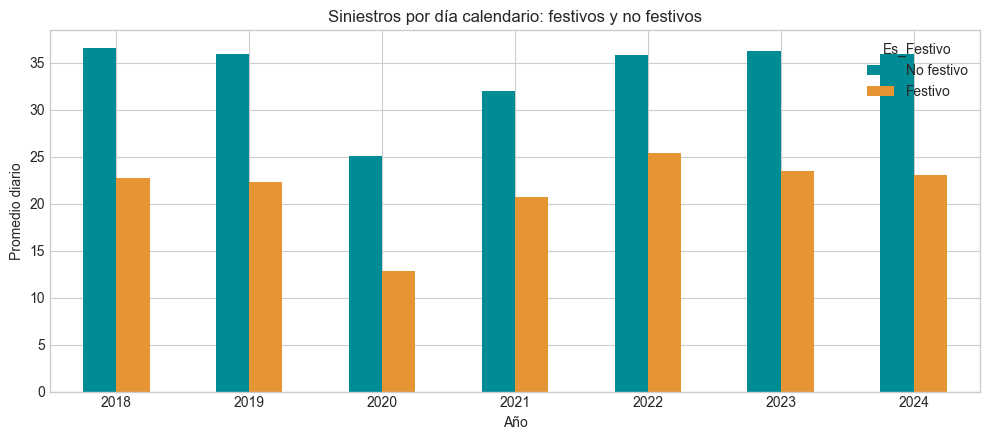

,Anio,Es_Festivo,Dias,Siniestros,Promedio_Diario
0,2018,False,347,12705,36.614
1,2018,True,18,410,22.778
2,2019,False,348,12489,35.888
3,2019,True,17,380,22.353
4,2020,False,348,8709,25.026
5,2020,True,18,231,12.833
6,2021,False,347,11095,31.974
7,2021,True,18,373,20.722
8,2022,False,347,12439,35.847
9,2022,True,18,457,25.389


,Dias_Festivos,Siniestros_Observados,Siniestros_Esperados_Mismo_Dia_Semana,Ratio_Observado_Esperado
Anio,,,,
2018,18,410,696.981,0.588
2019,17,380,625.179,0.608
2020,18,231,469.949,0.492
2021,18,373,588.134,0.634
2022,18,457,633.923,0.721
2023,18,422,660.399,0.639
2024,18,415,646.035,0.642


In [5]:
holiday_summary = daily.groupby(['Anio','Es_Festivo']).agg(
    Dias=('Fecha_Acc','size'),Siniestros=('Siniestros','sum'),Promedio_Diario=('Siniestros','mean')).reset_index()
nonholiday_mean = daily[~daily.Es_Festivo].groupby(['Anio','Dia_Num']).Siniestros.mean().rename('Esperado_No_Festivo')
holiday_matched = daily[daily.Es_Festivo].merge(nonholiday_mean,on=['Anio','Dia_Num'],validate='many_to_one')
assert holiday_matched.Esperado_No_Festivo.notna().all()
holiday_standard = holiday_matched.groupby('Anio').agg(
    Dias_Festivos=('Fecha_Acc','size'),Siniestros_Observados=('Siniestros','sum'),
    Siniestros_Esperados_Mismo_Dia_Semana=('Esperado_No_Festivo','sum'))
holiday_standard['Ratio_Observado_Esperado'] = holiday_standard.Siniestros_Observados/holiday_standard.Siniestros_Esperados_Mismo_Dia_Semana
export(holiday_summary,'festivos_por_anio.csv')
export(holiday_matched,'festivos_comparacion_dias_equivalentes.csv')
export(holiday_standard,'festivos_estandarizados_dia_semana.csv',index=True)
ax=holiday_summary.pivot(index='Anio',columns='Es_Festivo',values='Promedio_Diario').rename(columns={False:'No festivo',True:'Festivo'}).plot.bar(figsize=(10,4.5),color=['#008C95','#E59533'])
ax.set(title='Siniestros por día calendario: festivos y no festivos',ylabel='Promedio diario',xlabel='Año'); ax.tick_params(axis='x',rotation=0)
savefig('07_festivos_denominadores.png')
display(holiday_summary.round(3)); display(holiday_standard.round(3))

## 6. Actores involucrados: día, franja y localidad

Los indicadores `Con_Moto`, `Con_Peaton` y `Con_Bicicleta` identifican participación registrada en un siniestro. Las categorías pueden solaparse: sus conteos **no se suman como personas ni como total de siniestros únicos**. Un campo vacío se conserva como información no explícita, no como ausencia confirmada. Se reporta su calidad antes de los cruces.

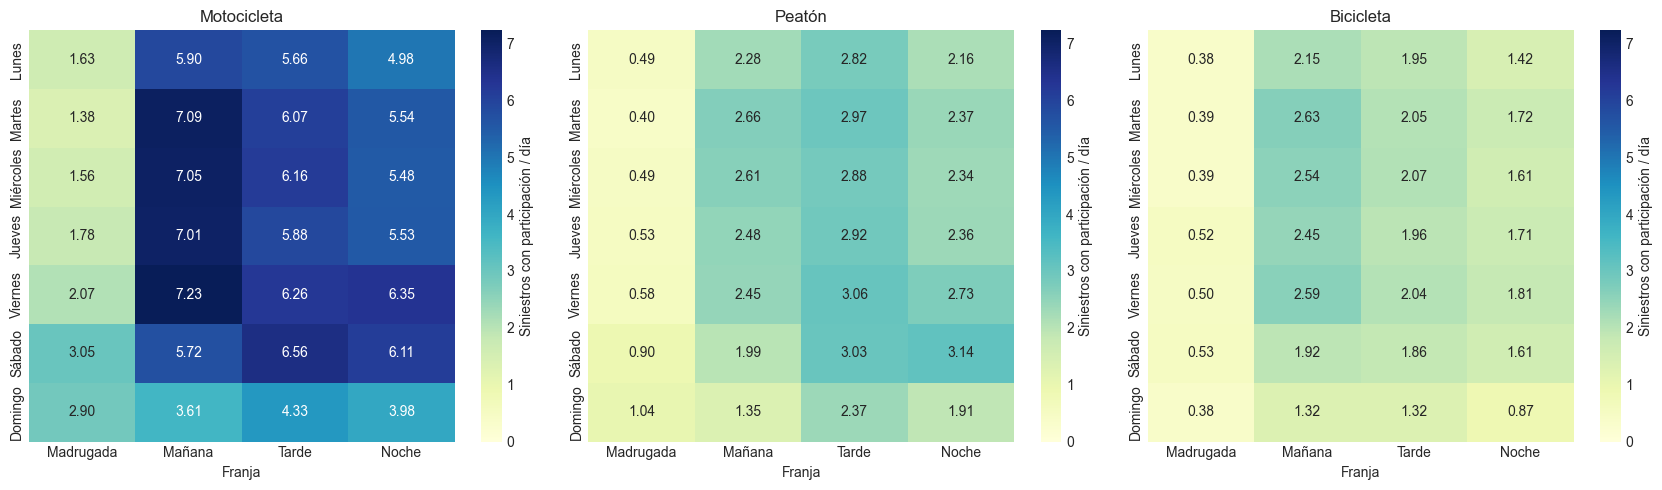

,Actor,Valor,Registros
0,Motocicleta,SI,50000
1,Motocicleta,Sin información explícita,35199
2,Peatón,Sin información explícita,64266
3,Peatón,SI,20933
4,Bicicleta,Sin información explícita,69616
5,Bicicleta,SI,15583


Actor,Bicicleta,Motocicleta,Peatón,Siniestros_Totales,Participacion_Motocicleta,Participacion_Peatón,Participacion_Bicicleta
Localidad,,,,,,,
ANTONIO NARIÑO,332,1409,504,2251,0.626,0.224,0.147
BARRIOS UNIDOS,523,1934,575,3280,0.590,0.175,0.159
BOSA,1648,3639,1601,6250,0.582,0.256,0.264
CANDELARIA,78,250,152,434,0.576,0.350,0.180
CHAPINERO,421,1616,782,3020,0.535,0.259,0.139
CIUDAD BOLÍVAR,606,2698,1493,4465,0.604,0.334,0.136
ENGATIVÁ,1750,4558,1710,7877,0.579,0.217,0.222
FONTIBÓN,1204,3140,972,5356,0.586,0.181,0.225
KENNEDY,2665,7070,2847,11879,0.595,0.240,0.224


In [6]:
flag_quality=[]; actor_long=[]
for name,column in FLAGS.items():
    normalized = victimas[column].astype('string').str.strip().str.upper()
    quality=normalized.fillna('Sin información explícita').value_counts().rename_axis('Valor').reset_index(name='Registros')
    quality.insert(0,'Actor',name); flag_quality.append(quality)
    part=victimas.loc[normalized.eq('SI').fillna(False),['Codigo_Accidente','Fecha_Acc','Localidad','Dia_Num','Franja_Horaria']].copy()
    part['Actor']=name; actor_long.append(part)
flag_quality=pd.concat(flag_quality,ignore_index=True)
actor_long=pd.concat(actor_long,ignore_index=True)
actor_index=pd.MultiIndex.from_product([list(FLAGS),range(7),SLOTS],names=['Actor','Dia_Num','Franja_Horaria'])
actor_day_slot=actor_long.groupby(['Actor','Dia_Num','Franja_Horaria'],observed=True).size().reindex(actor_index,fill_value=0).rename('Siniestros_Con_Participacion').reset_index()
actor_day_slot['Dias_Calendario']=actor_day_slot.Dia_Num.map(weekday_den)
actor_day_slot['Promedio_Diario']=actor_day_slot.Siniestros_Con_Participacion/actor_day_slot.Dias_Calendario
actor_day_slot['Dia_Semana']=actor_day_slot.Dia_Num.map(dict(enumerate(DAYS)))
actor_locality=actor_long.groupby(['Localidad','Actor']).size().unstack(fill_value=0).reindex(victimas.Localidad.sort_values().unique(),fill_value=0)
actor_locality['Siniestros_Totales']=victimas.groupby('Localidad').size()
for name in FLAGS: actor_locality['Participacion_'+name]=actor_locality[name]/actor_locality.Siniestros_Totales
export(flag_quality,'calidad_indicadores_actores.csv')
export(actor_day_slot,'actores_dia_semana_franja.csv')
export(actor_locality,'actores_por_localidad.csv',index=True)
fig,axes=plt.subplots(1,3,figsize=(17,5))
vmax=actor_day_slot.Promedio_Diario.max()
for ax,name in zip(axes,FLAGS):
    p=actor_day_slot[actor_day_slot.Actor.eq(name)].pivot(index='Dia_Semana',columns='Franja_Horaria',values='Promedio_Diario').reindex(index=DAYS,columns=SLOTS)
    sns.heatmap(p,annot=True,fmt='.2f',vmin=0,vmax=vmax,cmap='YlGnBu',ax=ax,cbar_kws={'label':'Siniestros con participación / día'})
    ax.set(title=name,xlabel='Franja',ylabel='')
savefig('08_actores_dia_franja.png')
display(flag_quality); display(actor_locality.round(3))

## 7. Hoja Actor_vial: registros de actores y gravedad

Se contrasta la hoja de actores con los siniestros incluidos, mediante unión muchos-a-uno. Las tablas distinguen **registros de actores** de **siniestros distintos** y conservan las categorías originales de gravedad. No se agregan víctimas únicas entre diferentes accidentes ni se usa información contemporánea de actores como predictor.

In [7]:
actors = pd.read_excel(RAW_FILE,sheet_name='Actor_vial',
                       usecols=['Codigo_Accidentado','Codigo_Accidente','Condicion','Condicion_Especifica','Gravedad_Indicador_Tradicional'])
actors_in_scope = actors.merge(victimas[['Codigo_Accidente','Fecha_Acc','Localidad','Franja_Horaria','Dia_Semana']],
                               on='Codigo_Accidente',how='inner',validate='many_to_one')
actor_integrity = pd.DataFrame([{
    'Registros_Actores':len(actors_in_scope),
    'IDs_Actores_Faltantes':int(actors_in_scope.Codigo_Accidentado.isna().sum()),
    'IDs_Actores_Duplicados':int(actors_in_scope.Codigo_Accidentado.duplicated().sum()),
    'Siniestros_Con_Actores':actors_in_scope.Codigo_Accidente.nunique(),
    'Siniestros_Sin_Fila_Actor':len(victimas)-actors_in_scope.Codigo_Accidente.nunique()}])
actor_person_summary = actors_in_scope.fillna({'Condicion_Especifica':'Sin información','Gravedad_Indicador_Tradicional':'Sin información'}).groupby(
    ['Condicion_Especifica','Gravedad_Indicador_Tradicional']).agg(
        Registros_Actores=('Codigo_Accidente','size'),Siniestros_Distintos=('Codigo_Accidente','nunique')).reset_index()
export(actor_integrity,'integridad_hoja_actores.csv')
export(actor_person_summary,'registros_actor_por_condicion_gravedad.csv')
actor_time = actors_in_scope.fillna({'Condicion_Especifica':'Sin información'}).groupby(
    ['Condicion_Especifica','Dia_Semana','Franja_Horaria'],observed=True).size().rename('Registros_Actores').reset_index()
export(actor_time,'registros_actor_condicion_dia_franja.csv')
display(actor_integrity); display(actor_person_summary.sort_values('Registros_Actores',ascending=False).head(25))
del actors, actors_in_scope

,Registros_Actores,IDs_Actores_Faltantes,IDs_Actores_Duplicados,Siniestros_Con_Actores,Siniestros_Sin_Fila_Actor
0,203548,0,0,85183,16


,Condicion_Especifica,Gravedad_Indicador_Tradicional,Registros_Actores,Siniestros_Distintos
27,Motociclista,HERIDO,48193,43798
9,Cond Livianos,ILESO,26493,25081
57,Peatón,HERIDO,21603,19552
17,Cond TPP,ILESO,14538,14173
0,Ciclista,HERIDO,14469,14244
41,Pasajero Motocicleta,HERIDO,12353,11857
8,Cond Livianos,HERIDO,10827,9740
53,Pasajero Transporte Pasajeros,HERIDO,10480,6633
21,Cond Taxi,ILESO,7916,7718
37,Pasajero Liviano,HERIDO,7137,4689


## 8. Cartografía oficial y control de coordenadas

Fuente: [servicio Localidad de Catastro Bogotá, atribución SDP](https://sig.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0). Se guarda una instantánea con URL, fecha y SHA-256; las siguientes ejecuciones usan esa copia. Se comprueban veinte localidades y geometrías válidas. El diccionario del Excel declara EPSG:4686 para los puntos; se transforman a EPSG:4326 para contrastar polígonos. Las discrepancias cerca de límites o de una capa actual requieren revisión, no eliminación automática. El antiguo rectángulo queda únicamente como ventana de acercamiento urbano.

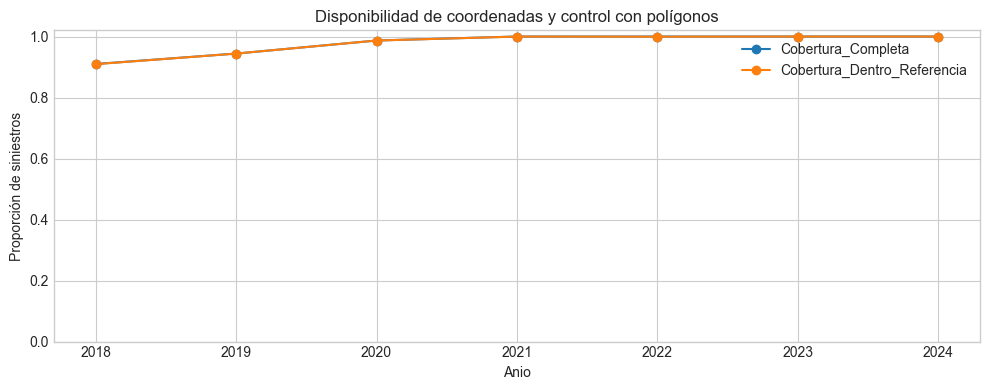

,Anio,Siniestros,Coordenadas_Completas,Coordenadas_En_Rango,Dentro_Distrito_Referencia,Cobertura_Completa,Cobertura_Dentro_Referencia
0,2018,13115,11934,11934,11927,0.9100,0.9094
1,2019,12869,12150,12150,12149,0.9441,0.9441
2,2020,8940,8823,8823,8822,0.9869,0.9868
3,2021,11468,11468,11468,11466,1.0000,0.9998
4,2022,12896,12896,12896,12889,1.0000,0.9995
5,2023,12999,12999,12999,12999,1.0000,1.0000
6,2024,12912,12912,12912,12912,1.0000,1.0000


,Fuera_Rectangulo_Urbano_Con_Coordenada,Dentro_Distrito_Fuera_Rectangulo,Fuera_Distrito_Con_Coordenada,Dentro_Distrito_Localidad_Distinta,Puntos_Limite_Compartido
0,9,9,18,5782,0


{'url': 'https://sig.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0/query?where=1%3D1&outFields=LOCNOMBRE%2CLOCCODIGO&returnGeometry=true&outSR=4326&f=geojson', 'servicio': 'https://sig.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0', 'atribucion': 'Secretaría Distrital de Planeación - SDP', 'consultado_utc': '2026-09-13T03:52:53.469465+00:00', 'sha256': '4dd83b3ba825c64e11e77a2aa39cbf505d2678a20d5ddba6217642f7b657344f', 'crs': 'EPSG:4326', 'alcance': 'Instantánea de referencia actual; no certifica límites históricos 2018–2024.'}


In [8]:
GEO_DIR=ROOT/'data/reference'; GEO_DIR.mkdir(parents=True,exist_ok=True)
GEO_FILE=GEO_DIR/'localidades_sdp_referencia.geojson'
GEO_META=GEO_DIR/'localidades_sdp_referencia_metadata.json'
SERVICE='https://sig.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0'
url=SERVICE+'/query?'+urllib.parse.urlencode({'where':'1=1','outFields':'LOCNOMBRE,LOCCODIGO','returnGeometry':'true','outSR':4326,'f':'geojson'})
if not GEO_FILE.exists():
    with urllib.request.urlopen(url,timeout=60) as response: payload=response.read()
    candidate=json.loads(payload)
    assert candidate.get('type')=='FeatureCollection' and len(candidate.get('features',[]))==20
    GEO_FILE.write_bytes(payload)
    GEO_META.write_text(json.dumps({'url':url,'servicio':SERVICE,'atribucion':'Secretaría Distrital de Planeación - SDP',
        'consultado_utc':datetime.now(timezone.utc).isoformat(),'sha256':sha256(payload).hexdigest(),
        'crs':'EPSG:4326','alcance':'Instantánea de referencia actual; no certifica límites históricos 2018–2024.'},indent=2,ensure_ascii=False),encoding='utf-8')
metadata_geo=json.loads(GEO_META.read_text())
assert sha256(GEO_FILE.read_bytes()).hexdigest()==metadata_geo['sha256']
features=json.loads(GEO_FILE.read_text())['features']
assert len(features)==20
def canonical(value):
    return ''.join(c for c in unicodedata.normalize('NFKD',str(value).upper()) if not unicodedata.combining(c)).replace('LA CANDELARIA','CANDELARIA').strip()
localities_geo={canonical(f['properties']['LOCNOMBRE']):shape(f['geometry']) for f in features}
assert len(localities_geo)==20 and all(g.is_valid for g in localities_geo.values())
city=shapely.union_all(list(localities_geo.values()))
coords=victimas[['Longitud','Latitud']].apply(pd.to_numeric,errors='coerce')
victimas['Coordenada_Completa']=coords.notna().all(axis=1)
victimas['Coordenada_Rango_Geografico']=victimas.Coordenada_Completa & np.isfinite(coords).all(axis=1) & coords.Longitud.between(-180,180) & coords.Latitud.between(-90,90)
valid_idx=victimas.index[victimas.Coordenada_Rango_Geografico]
to_wgs=Transformer.from_crs(4686,4326,always_xy=True)
lon,lat=to_wgs.transform(coords.loc[valid_idx,'Longitud'].to_numpy(),coords.loc[valid_idx,'Latitud'].to_numpy())
victimas.loc[valid_idx,'Lon_WGS84']=lon; victimas.loc[valid_idx,'Lat_WGS84']=lat
points=shapely.points(lon,lat); shapely.prepare(city)
victimas['Dentro_Poligono_Distrital']=False
victimas.loc[valid_idx,'Dentro_Poligono_Distrital']=shapely.covers(city,points)
victimas['Coordenada_En_Ventana_Urbana']=victimas.Longitud.between(-74.30,-73.90)&victimas.Latitud.between(4.40,4.90)
matches=np.zeros(len(points),dtype=int); assigned=np.full(len(points),'Fuera de polígonos',dtype=object)
for locality,g in localities_geo.items():
    shapely.prepare(g); hit=shapely.covers(g,points)
    assigned[hit]=locality; matches+=hit
assigned[matches>1]='Límite compartido'
victimas.loc[valid_idx,'Localidad_Por_Punto']=assigned
victimas['Localidad_Coincide_Punto']=victimas.Localidad.map(canonical).eq(victimas.Localidad_Por_Punto)
coverage=victimas.groupby('AA_Acc').agg(Siniestros=('Codigo_Accidente','size'),
    Coordenadas_Completas=('Coordenada_Completa','sum'),
    Coordenadas_En_Rango=('Coordenada_Rango_Geografico','sum'),
    Dentro_Distrito_Referencia=('Dentro_Poligono_Distrital','sum')).rename_axis('Anio').reset_index()
coverage['Cobertura_Completa']=coverage.Coordenadas_Completas/coverage.Siniestros
coverage['Cobertura_Dentro_Referencia']=coverage.Dentro_Distrito_Referencia/coverage.Siniestros
export(coverage,'cobertura_coordenadas.csv')
geo_issues=victimas[~victimas.Coordenada_Rango_Geografico | ~victimas.Dentro_Poligono_Distrital | ~victimas.Localidad_Coincide_Punto]
export(geo_issues[['Codigo_Accidente','Fecha_Acc','Localidad','Longitud','Latitud','Coordenada_Completa','Dentro_Poligono_Distrital','Localidad_Por_Punto']],'coordenadas_para_revision.csv')
geo_checks=pd.DataFrame([{'Fuera_Rectangulo_Urbano_Con_Coordenada':int((victimas.Coordenada_Rango_Geografico&~victimas.Coordenada_En_Ventana_Urbana).sum()),
    'Dentro_Distrito_Fuera_Rectangulo':int((victimas.Dentro_Poligono_Distrital&~victimas.Coordenada_En_Ventana_Urbana).sum()),
    'Fuera_Distrito_Con_Coordenada':int((victimas.Coordenada_Rango_Geografico&~victimas.Dentro_Poligono_Distrital).sum()),
    'Dentro_Distrito_Localidad_Distinta':int((victimas.Dentro_Poligono_Distrital&~victimas.Localidad_Coincide_Punto).sum()),
    'Puntos_Limite_Compartido':int((matches>1).sum())}])
export(geo_checks,'control_poligonos_y_rectangulo.csv')
coverage.plot(x='Anio',y=['Cobertura_Completa','Cobertura_Dentro_Referencia'],marker='o',figsize=(10,4))
plt.ylabel('Proporción de siniestros'); plt.ylim(0,1.02); plt.title('Disponibilidad de coordenadas y control con polígonos')
savefig('01_cobertura_coordenadas.png')
display(coverage.round(4)); display(geo_checks); print(metadata_geo)

## 9. Distribución territorial y mapa administrativo

Los totales se agrupan por la localidad declarada en la fuente, sin reasignaciones por coordenadas. La columna corregida `Siniestros_Con_Muertos` cuenta eventos. El mapa presenta volumen histórico registrado, no probabilidades ni predicciones del modelo.

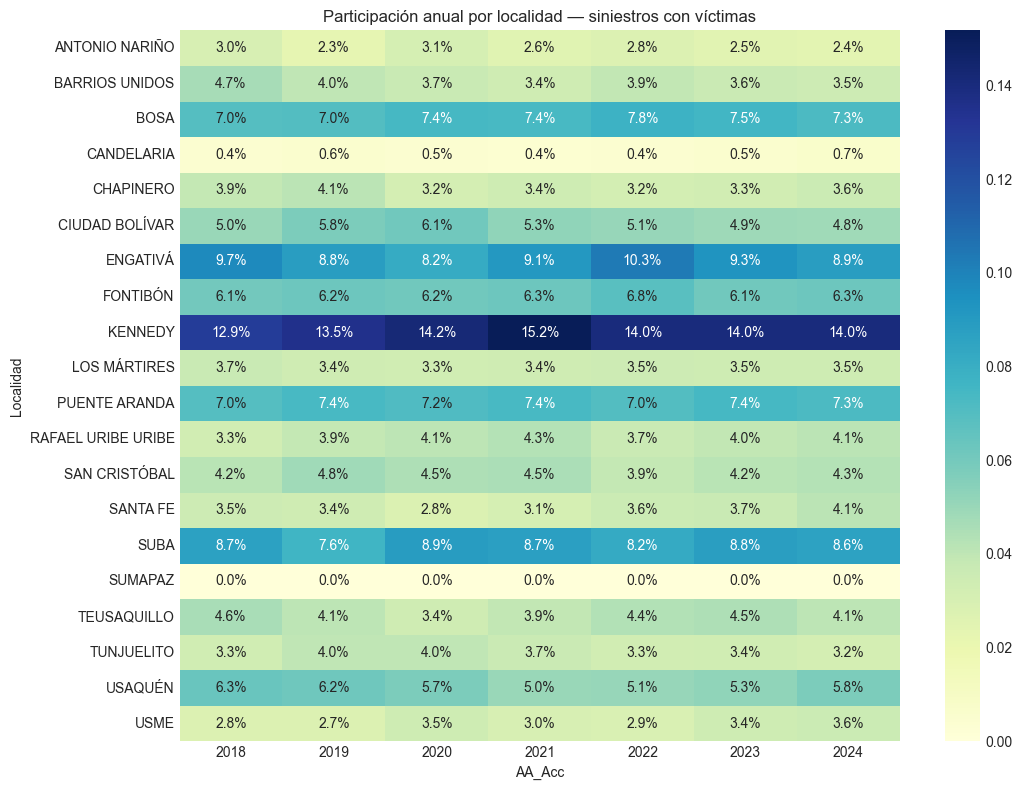

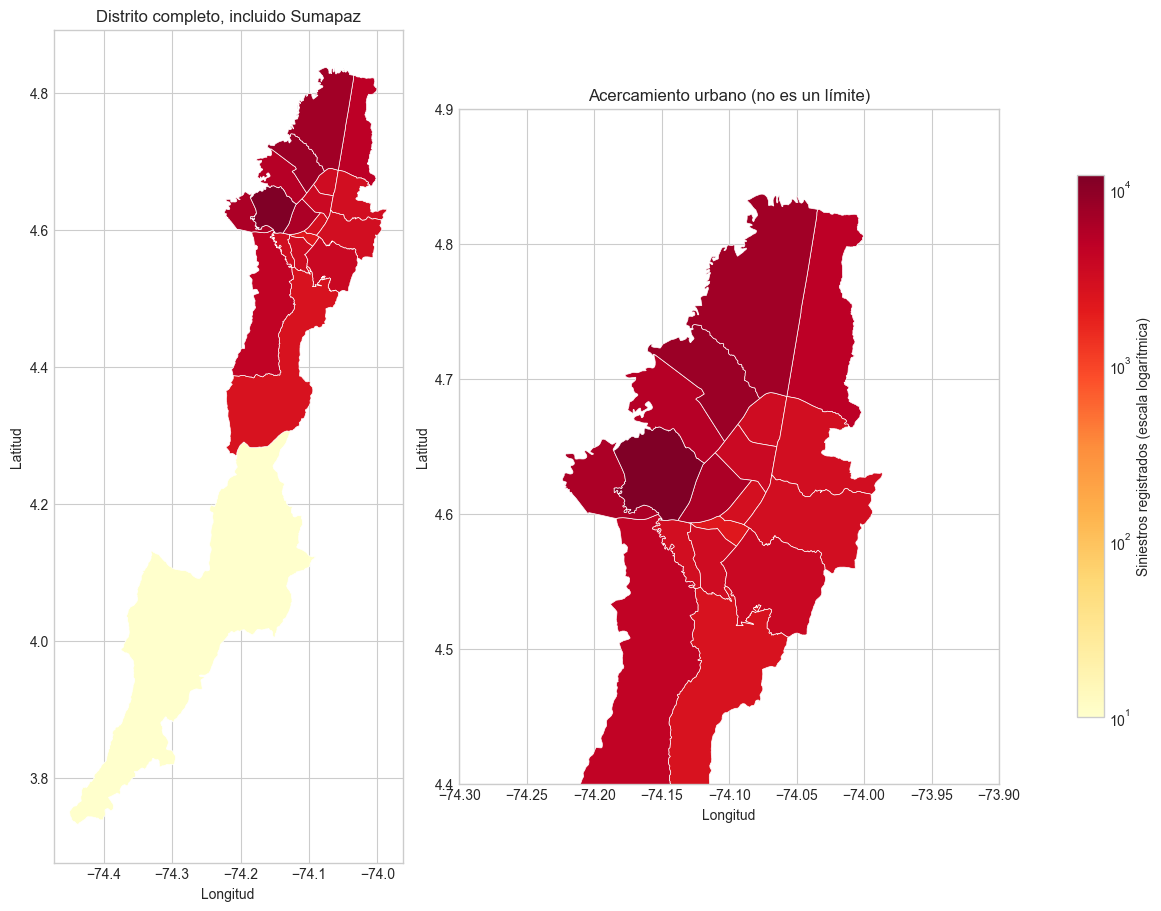

,Siniestros,Siniestros_Con_Muertos,Siniestros_Con_Peaton,Siniestros_Con_Moto,Siniestros_Con_Bicicleta,Cobertura_Coordenadas_Completas,Participacion_Ciudad
Localidad,,,,,,,
KENNEDY,11879,444,2847,7070,2665,0.9866,0.1394
ENGATIVÁ,7877,315,1710,4558,1750,0.9905,0.0925
SUBA,7235,271,1720,3993,1814,0.9961,0.0849
BOSA,6250,246,1601,3639,1648,0.9619,0.0734
PUENTE ARANDA,6166,243,1181,3933,1107,0.9690,0.0724
FONTIBÓN,5356,258,972,3140,1204,0.9901,0.0629
USAQUÉN,4802,190,1095,2552,720,0.9704,0.0564
CIUDAD BOLÍVAR,4465,249,1493,2698,606,0.9702,0.0524
SAN CRISTÓBAL,3693,138,1224,2224,361,0.9540,0.0433


In [9]:
summary=victimas.groupby('Localidad').agg(Siniestros=('Codigo_Accidente','size'),
    Siniestros_Con_Muertos=('Gravedad_Indicador_Tradicional',lambda s:s.eq('Con Muertos').sum()),
    Siniestros_Con_Peaton=('Con_Peaton',lambda s:s.eq('SI').sum()),
    Siniestros_Con_Moto=('Con_Moto',lambda s:s.eq('SI').sum()),
    Siniestros_Con_Bicicleta=('Con_Bicicleta',lambda s:s.eq('SI').sum()),
    Cobertura_Coordenadas_Completas=('Coordenada_Completa','mean')).sort_values('Siniestros',ascending=False)
summary['Participacion_Ciudad']=summary.Siniestros/summary.Siniestros.sum()
export(summary,'resumen_localidades.csv',index=True)
annual_locality=victimas.groupby(['Localidad','AA_Acc']).size().unstack(fill_value=0)
plt.figure(figsize=(11,8)); sns.heatmap(annual_locality.div(annual_locality.sum(axis=0),axis=1),cmap='YlGnBu',fmt='.1%',annot=True)
plt.title('Participación anual por localidad — siniestros con víctimas'); savefig('02_distribucion_anual_localidad.png')
def parts(geometry):
    return [geometry] if geometry.geom_type=='Polygon' else list(geometry.geoms)
def draw_boundaries(ax):
    for geom in localities_geo.values():
        for poly in parts(geom):
            x,y=poly.exterior.xy; ax.plot(x,y,color='#555555',lw=.55)
volume={canonical(k):v for k,v in summary.Siniestros.items()}
norm=LogNorm(vmin=max(1,min(volume.values())),vmax=max(volume.values()))
fig,axes=plt.subplots(1,2,figsize=(13,9),layout='constrained')
for ax in axes:
    for name,geom in localities_geo.items():
        for poly in parts(geom):
            x,y=poly.exterior.xy; ax.fill(x,y,color=plt.cm.YlOrRd(norm(volume.get(name,1))),ec='white',lw=.5)
    ax.set_aspect('equal'); ax.set(xlabel='Longitud',ylabel='Latitud')
axes[0].set_title('Distrito completo, incluido Sumapaz')
axes[1].set(xlim=(-74.30,-73.90),ylim=(4.40,4.90),title='Acercamiento urbano (no es un límite)')
fig.colorbar(ScalarMappable(norm=norm,cmap='YlOrRd'),ax=axes.tolist(),label='Siniestros registrados (escala logarítmica)',shrink=.65)

plt.savefig(REPORTS_PATH/'09_mapa_localidades_oficial.png',dpi=170,bbox_inches='tight'); plt.show(); plt.close()
display(summary.round(4))

## 10. Concentración puntual, centros medianos y celdas métricas

Los mapas de puntos utilizan los registros dentro del polígono distrital de referencia; los excluidos permanecen en los totales y se exportan para revisión. Las dos densidades usan la misma escala de conteo. Los centros medianos describen la ubicación de los siniestros, no centroides administrativos. Las celdas son de **100 × 100 metros** en EPSG:9377, no redondeos de grados. No se utilizan como unidades predictivas ni como tasas por exposición.

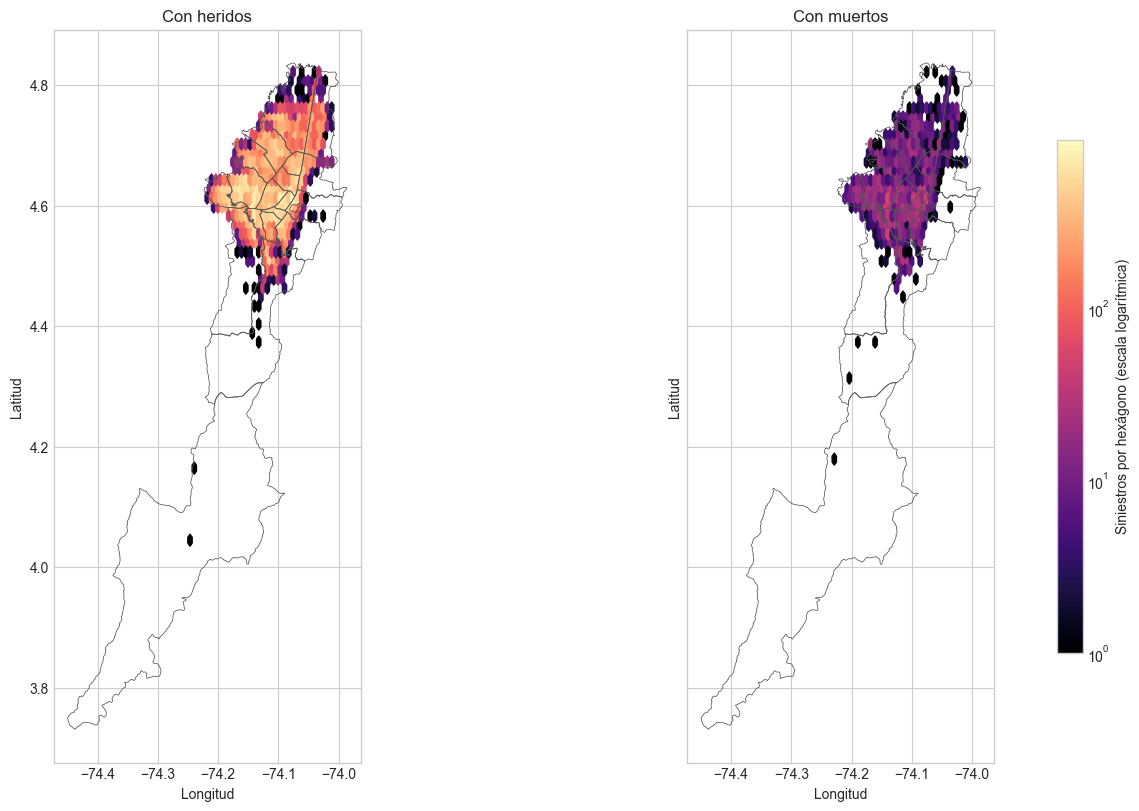

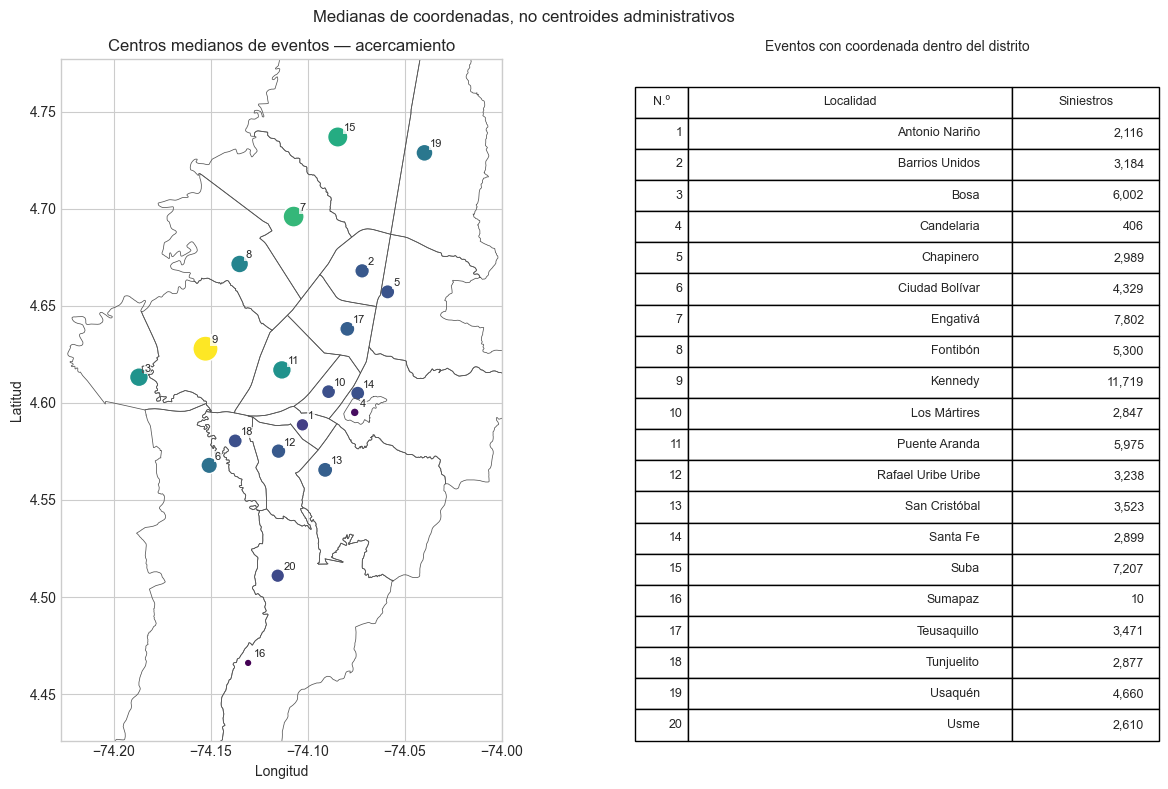

,Celda_Este_100m,Celda_Norte_100m,Siniestros,Localidad_Declarada_Dominante,Siniestros_Con_Muertos,CRS,Lado_Celda_Metros
10553,48782,20685,307,KENNEDY,10,EPSG:9377,100
4736,48738,20697,148,KENNEDY,5,EPSG:9377,100
6988,48758,20751,104,FONTIBÓN,7,EPSG:9377,100
4444,48736,20634,101,TUNJUELITO,5,EPSG:9377,100
5001,48740,20729,92,FONTIBÓN,9,EPSG:9377,100
13850,48807,20675,90,SANTA FE,5,EPSG:9377,100
4479,48736,20684,88,KENNEDY,15,EPSG:9377,100
11107,48786,20637,84,SAN CRISTÓBAL,3,EPSG:9377,100
1077,48692,20660,82,BOSA,5,EPSG:9377,100
12764,48797,20660,79,SANTA FE,6,EPSG:9377,100


In [10]:
geo=victimas[victimas.Dentro_Poligono_Distrital].copy()
fig,axes=plt.subplots(1,2,figsize=(14,8),sharex=True,sharey=True,layout='constrained')
extent=city.bounds; hex_extent=(extent[0],extent[2],extent[1],extent[3]); bins=[]
for ax,(label,part) in zip(axes,[('Con heridos',geo[geo.Gravedad_Indicador_Tradicional.eq('Con Heridos')]),('Con muertos',geo[geo.Gravedad_Indicador_Tradicional.eq('Con Muertos')])]):
    hb=ax.hexbin(part.Lon_WGS84,part.Lat_WGS84,gridsize=65,mincnt=1,cmap='magma',extent=hex_extent)
    bins.append(hb); draw_boundaries(ax); ax.set(title=label,xlabel='Longitud',ylabel='Latitud',aspect='equal')
common_norm=LogNorm(vmin=1,vmax=max(float(h.get_array().max()) for h in bins))
for hb in bins: hb.set_norm(common_norm)
fig.colorbar(bins[0],ax=axes.tolist(),label='Siniestros por hexágono (escala logarítmica)',shrink=.7)

plt.savefig(REPORTS_PATH/'03_densidad_espacial_victimas.png',dpi=170,bbox_inches='tight'); plt.show(); plt.close()
centers=geo.groupby('Localidad').agg(Longitud=('Lon_WGS84','median'),Latitud=('Lat_WGS84','median'),Siniestros=('Codigo_Accidente','size')).reset_index()
export(centers,'centros_medianos_siniestros.csv')
fig,(ax,legend_ax)=plt.subplots(1,2,figsize=(13,8),gridspec_kw={'width_ratios':[1.5,1]})
draw_boundaries(ax)
ax.scatter(centers.Longitud,centers.Latitud,s=30+300*centers.Siniestros/centers.Siniestros.max(),c=centers.Siniestros,cmap='viridis',edgecolor='white')
for i,r in centers.iterrows():
    ax.annotate(str(i+1),(r.Longitud,r.Latitud),xytext=(4,4),textcoords='offset points',
                fontsize=8,bbox=dict(facecolor='white',edgecolor='none',alpha=.8,pad=.5))
ax.set(title='Centros medianos de eventos — acercamiento',xlabel='Longitud',ylabel='Latitud',aspect='equal',
       xlim=(centers.Longitud.min()-.04,centers.Longitud.max()+.04),
       ylim=(centers.Latitud.min()-.04,centers.Latitud.max()+.04))
legend_ax.axis('off')
table=legend_ax.table(cellText=[[i+1,r.Localidad.title(),f'{r.Siniestros:,}'] for i,r in centers.iterrows()],
                     colLabels=['N.º','Localidad','Siniestros'],colWidths=[.1,.62,.28],bbox=[0,0,1,.96])
table.auto_set_font_size(False); table.set_fontsize(9)
legend_ax.set_title('Eventos con coordenada dentro del distrito',fontsize=10)
fig.suptitle('Medianas de coordenadas, no centroides administrativos',fontsize=12)
savefig('04_centros_localidad.png')
to_metric=Transformer.from_crs(4326,9377,always_xy=True)
xx,yy=to_metric.transform(geo.Lon_WGS84.to_numpy(),geo.Lat_WGS84.to_numpy())
geo['Celda_Este_100m']=np.floor(np.asarray(xx)/100).astype(int)
geo['Celda_Norte_100m']=np.floor(np.asarray(yy)/100).astype(int)
hotspots=geo.groupby(['Celda_Este_100m','Celda_Norte_100m']).agg(
    Siniestros=('Codigo_Accidente','size'),Localidad_Declarada_Dominante=('Localidad',lambda s:s.mode().iat[0]),
    Siniestros_Con_Muertos=('Gravedad_Indicador_Tradicional',lambda s:s.eq('Con Muertos').sum())).reset_index().sort_values('Siniestros',ascending=False)
hotspots['CRS']='EPSG:9377'; hotspots['Lado_Celda_Metros']=100
export(hotspots.head(25),'top25_celdas_concentracion.csv')
assert hotspots.Siniestros.sum()==len(geo)
display(hotspots.head(25))

## 11. Estabilidad territorial con sensibilidad a 2020

Se comparan promedios por día, no totales de periodos de cinco y dos años. También se muestra el periodo de entrenamiento sin 2020. Excluir ese año es una sensibilidad descriptiva, no una propuesta de eliminarlo del entrenamiento. La razón posterior/anterior no prueba que la cobertura sea idéntica.

,Siniestros_Pre,Siniestros_Post,Siniestros_Pre_Sin2020,Dias_Pre,Dias_Post,Dias_Pre_Sin2020,Promedio_Diario_Pre,Promedio_Diario_Post,Promedio_Diario_Pre_Sin2020,Ratio_Post_Pre,Ratio_Post_Pre_Sin2020
Localidad,,,,,,,,,,,
ANTONIO NARIÑO,1614,637,1336,1826,731,1460,0.884,0.871,0.915,0.986,0.952
BARRIOS UNIDOS,2356,924,2025,1826,731,1460,1.290,1.264,1.387,0.980,0.911
BOSA,4332,1918,3667,1826,731,1460,2.372,2.624,2.512,1.106,1.045
CANDELARIA,272,162,230,1826,731,1460,0.149,0.222,0.158,1.488,1.407
CHAPINERO,2130,890,1846,1826,731,1460,1.166,1.218,1.264,1.044,0.963
CIUDAD BOLÍVAR,3202,1263,2654,1826,731,1460,1.754,1.728,1.818,0.985,0.950
ENGATIVÁ,5518,2359,4787,1826,731,1460,3.022,3.227,3.279,1.068,0.984
FONTIBÓN,3748,1608,3198,1826,731,1460,2.053,2.200,2.190,1.072,1.004
KENNEDY,8246,3633,6979,1826,731,1460,4.516,4.970,4.780,1.101,1.040


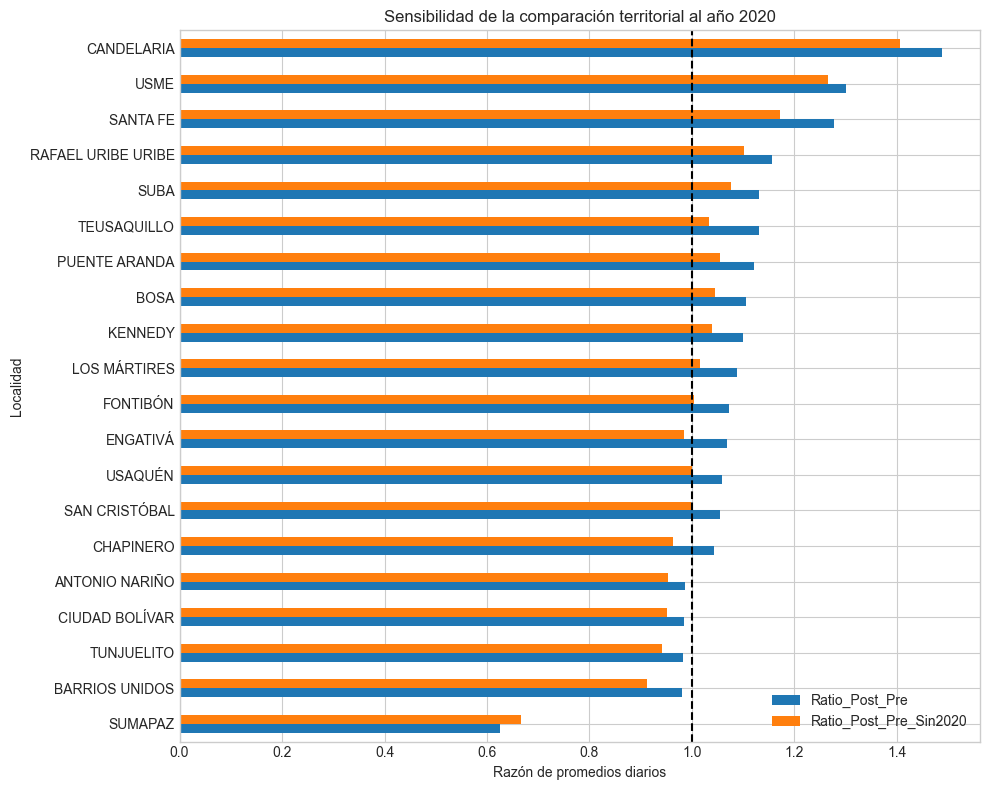

In [11]:
den_pre=int(calendar.Anio.le(2022).sum()); den_post=int(calendar.Anio.ge(2023).sum())
den_pre_no2020=int((calendar.Anio.le(2022)&calendar.Anio.ne(2020)).sum())
pre=victimas[victimas.AA_Acc.le(2022)].groupby('Localidad').size()
post=victimas[victimas.AA_Acc.ge(2023)].groupby('Localidad').size()
pre_no2020=victimas[victimas.AA_Acc.le(2022)&victimas.AA_Acc.ne(2020)].groupby('Localidad').size()
stability=pd.concat([pre.rename('Siniestros_Pre'),post.rename('Siniestros_Post'),pre_no2020.rename('Siniestros_Pre_Sin2020')],axis=1).fillna(0)
stability['Dias_Pre']=den_pre; stability['Dias_Post']=den_post; stability['Dias_Pre_Sin2020']=den_pre_no2020
stability['Promedio_Diario_Pre']=stability.Siniestros_Pre/den_pre
stability['Promedio_Diario_Post']=stability.Siniestros_Post/den_post
stability['Promedio_Diario_Pre_Sin2020']=stability.Siniestros_Pre_Sin2020/den_pre_no2020
stability['Ratio_Post_Pre']=stability.Promedio_Diario_Post/stability.Promedio_Diario_Pre.replace(0,np.nan)
stability['Ratio_Post_Pre_Sin2020']=stability.Promedio_Diario_Post/stability.Promedio_Diario_Pre_Sin2020.replace(0,np.nan)
export(stability,'estabilidad_territorial_periodos.csv',index=True)
display(stability.round(3))
stability[['Ratio_Post_Pre','Ratio_Post_Pre_Sin2020']].sort_values('Ratio_Post_Pre').plot.barh(figsize=(10,8))
plt.axvline(1,color='black',ls='--'); plt.xlabel('Razón de promedios diarios'); plt.title('Sensibilidad de la comparación territorial al año 2020')
savefig('10_estabilidad_sensibilidad_2020.png')

## 12. Conclusión ejecutiva y verificación

Las conclusiones se generan con las tablas calculadas. Los resultados cumplen un alcance descriptivo espacial, temporal y por actor; las tasas por exposición, causalidad, límites históricos y predicciones geográficas son problemas distintos.

In [12]:
peak=weekday_slot.loc[weekday_slot.Promedio_Diario.idxmax()]
holiday_ratio=holiday_matched.Siniestros.sum()/holiday_matched.Esperado_No_Festivo.sum()
actor_peaks=actor_day_slot.loc[actor_day_slot.groupby('Actor').Promedio_Diario.idxmax()]
conclusion=f"""# Conclusión ejecutiva — actividad 3.1

Se analizaron {len(victimas):,} siniestros con víctimas del indicador tradicional, en 2.557 días de 2018–2024.
Se mantuvo intacto el dataset del modelo. Las observaciones son siniestros registrados, no personas ni tasas de riesgo individual.

## Patrones temporales

La combinación de mayor promedio diario es {peak.Dia_Semana}–{peak.Franja_Horaria}: {peak.Promedio_Diario:.2f} siniestros por día de ese tipo.
La serie mensual utiliza días calendario como denominador. En 2020 el promedio diario equivale a
{annual.loc[2020,'Ratio_vs_2018_2019']:.3f} veces el de 2018–2019.
La sensibilidad sin 2020 muestra cuánto influye ese año en la comparación de periodos; no estima un efecto causal.

En festivos, el cociente de siniestros observados frente a los esperados según días no festivos del mismo año
y día de semana es {holiday_ratio:.3f}. Es una comparación descriptiva ajustada por esa composición,
no por exposición al tránsito ni otras variables.

## Actores

Se exportaron cruces de participación registrada de motocicleta, peatón y bicicleta por día, franja y localidad.
Las categorías se solapan y los campos vacíos no son ausencias confirmadas.
También se cruzó la hoja Actor_vial: {int(actor_integrity.iloc[0].Registros_Actores):,} registros asociados,
separando registros de actores de siniestros distintos. Su integridad se informa en una tabla específica.

## Territorio y coordenadas

{summary.index[0]} concentra {int(summary.iloc[0].Siniestros):,} siniestros ({summary.iloc[0].Participacion_Ciudad:.2%}).
La cobertura de coordenadas completas es {coverage.iloc[0].Cobertura_Completa:.2%} en 2018 y
{coverage.iloc[-1].Cobertura_Completa:.2%} en 2024.
Se usaron veinte polígonos oficiales de referencia SDP/Catastro. Hay
{int(geo_checks.iloc[0].Dentro_Distrito_Fuera_Rectangulo)} puntos dentro del distrito pero fuera del antiguo rectángulo urbano;
no se excluyen por ese rectángulo.
Se identifican {int(geo_checks.iloc[0].Fuera_Distrito_Con_Coordenada)} puntos fuera del distrito de referencia y
{int(geo_checks.iloc[0].Dentro_Distrito_Localidad_Distinta)} dentro del distrito cuya localidad declarada no coincide con el polígono.
Se exportan para revisión; no se corrigen automáticamente ni se reasignan registros.
La cartografía actual no certifica los límites históricos ni elimina la incertidumbre de geocodificación.

Se corrigió Fallecidos por Siniestros_Con_Muertos. Los centros son medianas de eventos, no centroides administrativos.
Las concentraciones puntuales usan celdas de 100 × 100 m en EPSG:9377 y mapas con escala de conteo explícita.
El mapa administrativo usa los conteos por localidad declarada, no scores del modelo.

## Alcance

El cambio de indicador tradicional a treinta días modifica la pertenencia de
{int(gravity_membership.iloc[0].Salen_Al_Cambiar+gravity_membership.iloc[0].Entran_Al_Cambiar)} registros.
La definición del modelo se conserva. No se demuestra cobertura perfecta, causalidad,
riesgo por persona ni eficacia de intervenciones. Las diferencias por exposición requieren denominadores adicionales.

Fuente cartográfica: {SERVICE}
Instantánea y procedencia: data/reference/localidades_sdp_referencia_metadata.json.
"""
(REPORTS_PATH/'conclusion_ejecutiva.md').write_text(conclusion,encoding='utf-8')
export(actor_peaks,'resumen_picos_actores.csv')
for path,digest in protected_hashes.items():
    assert sha256(path.read_bytes()).hexdigest()==digest, f'Cambió un archivo protegido: {path}'
checks={'siniestros':len(victimas),'dias':len(calendar),'total_diario_coincide':int(daily.Siniestros.sum())==len(victimas),
        'combinaciones_dia_franja':len(weekday_slot),'combinaciones_actor_dia_franja':len(actor_day_slot),
        'poligonos':len(localities_geo),'geometrias_validas':all(g.is_valid for g in localities_geo.values()),
        'datos_y_modelos_intactos':True,'fuente_cartografica_sha256':metadata_geo['sha256']}
(REPORTS_PATH/'verificacion_actividad_3_1.json').write_text(json.dumps(checks,indent=2,ensure_ascii=False),encoding='utf-8')
print(conclusion); print(checks)

# Conclusión ejecutiva — actividad 3.1

Se analizaron 85,199 siniestros con víctimas del indicador tradicional, en 2.557 días de 2018–2024.
Se mantuvo intacto el dataset del modelo. Las observaciones son siniestros registrados, no personas ni tasas de riesgo individual.

## Patrones temporales

La combinación de mayor promedio diario es Martes–Mañana: 12.19 siniestros por día de ese tipo.
La serie mensual utiliza días calendario como denominador. En 2020 el promedio diario equivale a
0.686 veces el de 2018–2019.
La sensibilidad sin 2020 muestra cuánto influye ese año en la comparación de periodos; no estima un efecto causal.

En festivos, el cociente de siniestros observados frente a los esperados según días no festivos del mismo año
y día de semana es 0.622. Es una comparación descriptiva ajustada por esa composición,
no por exposición al tránsito ni otras variables.

## Actores

Se exportaron cruces de participación registrada de motocicleta, peatón y bicicleta por día, franja y loca